# 01 — MMASH Dataset: Exploration & HRV Analysis

**Dataset**: MMASH — Multilevel Monitoring of Activity and Sleep in Healthy People  
**Source**: https://physionet.org/content/mmash/1.0.0/

The MMASH dataset contains 2-day recordings from 22 healthy participants:
- Triaxial accelerometry (Actigraph)
- RR intervals (heart rate variability)
- Sleep diary & activity logs
- 12 labelled activity types

---

## Pipeline
1. Behavior/activity distribution
2. RR interval timeseries & rolling mean
3. RMSSD (HRV) windowed computation
4. RR interval distribution

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': '#0d1117',
    'axes.facecolor':   '#161b22',
    'axes.edgecolor':   '#30363d',
    'axes.labelcolor':  '#8b949e',
    'xtick.color':      '#8b949e',
    'ytick.color':      '#8b949e',
    'text.color':       '#e6edf3',
    'grid.color':       '#21262d',
    'grid.linewidth':   0.5,
    'axes.grid':        True,
})

BLUE   = '#58a6ff'
GREEN  = '#3fb950'
RED    = '#f78166'
PURPLE = '#d2a8ff'
ORANGE = '#ffa657'
MUTED  = '#8b949e'
TEXT   = '#e6edf3'

np.random.seed(42)
print('Libraries loaded ✓')
print('NOTE: Replace simulated data with real MMASH files from PhysioNet.')

Libraries loaded ✓
NOTE: Replace simulated data with real MMASH files from PhysioNet.


## 1. Activity / Behavior Distribution

The MMASH activity diary contains 12 behaviour categories logged per subject.
Here we visualise time spent per category for a single participant (User 1).

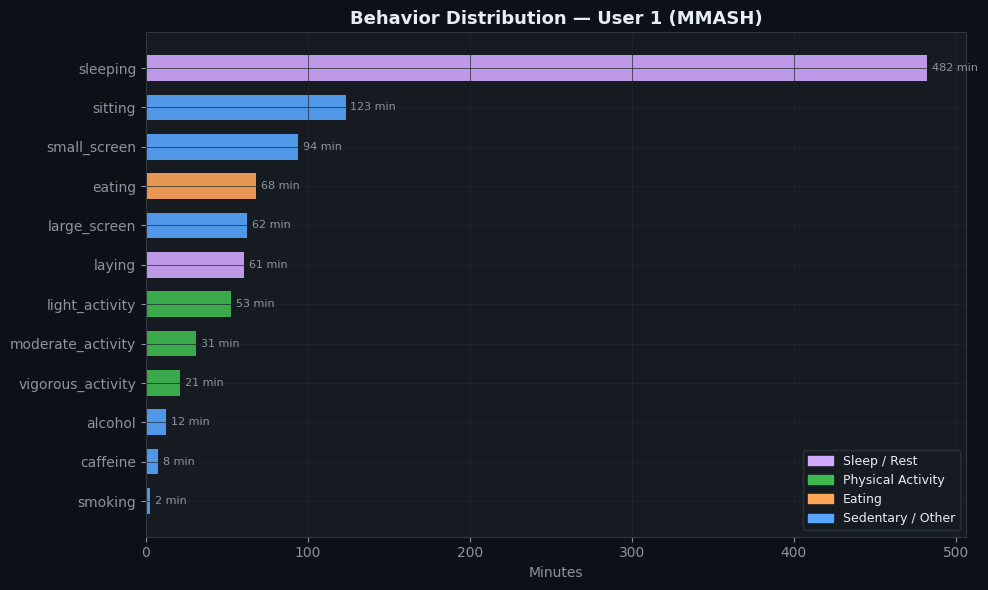

In [2]:
activity_map = {
    1: 'sleeping',        2: 'laying',           3: 'sitting',
    4: 'light_activity',  5: 'moderate_activity', 6: 'vigorous_activity',
    7: 'eating',          8: 'small_screen',      9: 'large_screen',
    10: 'caffeine',       11: 'smoking',          12: 'alcohol'
}

# Simulated — replace with: pd.read_csv('data/DataPaper/user_1/activity.csv')
durations  = np.array([480, 60, 120, 45, 30, 20, 60, 90, 60, 5, 0, 10], dtype=float)
durations += np.abs(np.random.normal(0, 5, len(durations)))
labels     = list(activity_map.values())

order      = np.argsort(durations)
active_set = {'light_activity', 'moderate_activity', 'vigorous_activity'}
sleep_set  = {'sleeping', 'laying'}

bar_colors = []
for l in np.array(labels)[order]:
    if l in active_set:  bar_colors.append(GREEN)
    elif l in sleep_set: bar_colors.append(PURPLE)
    elif l == 'eating':  bar_colors.append(ORANGE)
    else:                bar_colors.append(BLUE)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(np.array(labels)[order], durations[order],
               color=bar_colors, height=0.65, alpha=0.9)
ax.set_facecolor('#161b22')
ax.set_xlabel('Minutes')
ax.set_title('Behavior Distribution — User 1 (MMASH)', fontsize=13, fontweight='bold')
for spine in ax.spines.values():
    spine.set_edgecolor('#30363d')
for bar, val in zip(bars, durations[order]):
    ax.text(val + 3, bar.get_y() + bar.get_height()/2,
            f'{val:.0f} min', va='center', color=MUTED, fontsize=8)
patches = [
    mpatches.Patch(color=PURPLE, label='Sleep / Rest'),
    mpatches.Patch(color=GREEN,  label='Physical Activity'),
    mpatches.Patch(color=ORANGE, label='Eating'),
    mpatches.Patch(color=BLUE,   label='Sedentary / Other'),
]
ax.legend(handles=patches, loc='lower right',
          facecolor='#161b22', edgecolor='#30363d', labelcolor=TEXT, fontsize=9)
plt.tight_layout()
plt.savefig('../figures/01_behavior_distribution.png', dpi=160,
            bbox_inches='tight', facecolor='#0d1117')
plt.show()

## 2. RR Interval Timeseries + RMSSD + Distribution

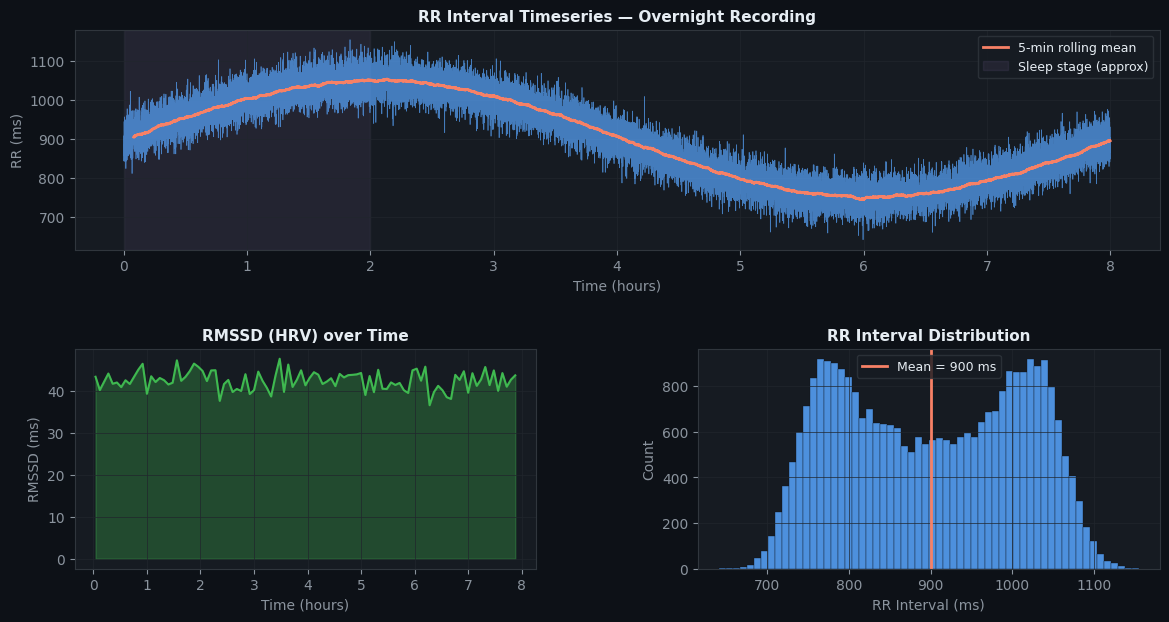

Mean RR   : 900 ms
Mean RMSSD: 42.4 ms
Mean HR   : 66.7 bpm


In [3]:
# Simulated — replace with: pd.read_csv('data/DataPaper/user_1/RR.csv')
t_rr  = np.linspace(0, 8 * 3600, 30000)
rr_ms = 900 + 150 * np.sin(2 * np.pi * t_rr / (8 * 3600)) + np.random.normal(0, 30, len(t_rr))
rr_ms = rr_ms.clip(600, 1300)
hours = t_rr / 3600

win = 300
rmssd_vals, rmssd_t = [], []
for i in range(0, len(rr_ms) - win, win):
    diffs = np.diff(rr_ms[i:i + win])
    rmssd_vals.append(np.sqrt(np.mean(diffs ** 2)))
    rmssd_t.append(t_rr[i + win // 2] / 3600)
rmssd_vals = np.array(rmssd_vals)
rmssd_t    = np.array(rmssd_t)

fig = plt.figure(figsize=(14, 7))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

ax0 = fig.add_subplot(gs[0, :])
ax0.plot(hours, rr_ms, color=BLUE, lw=0.5, alpha=0.7)
rm = pd.Series(rr_ms).rolling(300).mean()
ax0.plot(hours, rm, color=RED, lw=2, label='5-min rolling mean')
ax0.axvspan(0, 2, alpha=0.07, color=PURPLE, label='Sleep stage (approx)')
ax0.set_xlabel('Time (hours)')
ax0.set_ylabel('RR (ms)')
ax0.set_title('RR Interval Timeseries — Overnight Recording', fontsize=11, fontweight='bold')
ax0.legend(facecolor='#161b22', edgecolor='#30363d', labelcolor=TEXT, fontsize=9)
ax0.set_facecolor('#161b22')
for spine in ax0.spines.values(): spine.set_edgecolor('#30363d')

ax1 = fig.add_subplot(gs[1, 0])
ax1.fill_between(rmssd_t, rmssd_vals, alpha=0.3, color=GREEN)
ax1.plot(rmssd_t, rmssd_vals, color=GREEN, lw=1.5)
ax1.set_xlabel('Time (hours)')
ax1.set_ylabel('RMSSD (ms)')
ax1.set_title('RMSSD (HRV) over Time', fontsize=11, fontweight='bold')
ax1.set_facecolor('#161b22')
for spine in ax1.spines.values(): spine.set_edgecolor('#30363d')

ax2 = fig.add_subplot(gs[1, 1])
ax2.hist(rr_ms, bins=60, color=BLUE, alpha=0.85, edgecolor='#0d1117', lw=0.3)
ax2.axvline(np.mean(rr_ms), color=RED, lw=2, label=f'Mean = {np.mean(rr_ms):.0f} ms')
ax2.set_xlabel('RR Interval (ms)')
ax2.set_ylabel('Count')
ax2.set_title('RR Interval Distribution', fontsize=11, fontweight='bold')
ax2.legend(facecolor='#161b22', edgecolor='#30363d', labelcolor=TEXT, fontsize=9)
ax2.set_facecolor('#161b22')
for spine in ax2.spines.values(): spine.set_edgecolor('#30363d')

fig.patch.set_facecolor('#0d1117')
plt.savefig('../figures/01_rr_hrv.png', dpi=160, bbox_inches='tight', facecolor='#0d1117')
plt.show()

print(f'Mean RR   : {np.mean(rr_ms):.0f} ms')
print(f'Mean RMSSD: {np.mean(rmssd_vals):.1f} ms')
print(f'Mean HR   : {60000 / np.mean(rr_ms):.1f} bpm')

## 3. Loading Real MMASH Data

Once you download the dataset from PhysioNet, replace the simulated sections above.

In [4]:
# DATA_PATH = '../data/DataPaper/'
# user_id   = 'user_1'

# activity_df = pd.read_csv(f'{DATA_PATH}{user_id}/activity.csv')
# print(activity_df.head())

# rr_df = pd.read_csv(f'{DATA_PATH}{user_id}/RR.csv')
# rr_ms_real = rr_df['RR'].values * 1000
# print(rr_df.head())

# accel_df = pd.read_csv(f'{DATA_PATH}{user_id}/accel.csv')
# print(accel_df.head())

print('Uncomment above after downloading MMASH from PhysioNet.')
print('Dataset: https://physionet.org/content/mmash/1.0.0/')

Uncomment above after downloading MMASH from PhysioNet.
Dataset: https://physionet.org/content/mmash/1.0.0/


## Summary

| Metric | Value |
|--------|-------|
| Dataset | MMASH — 22 subjects, 2-day recordings |
| Signals | RR intervals, accelerometer, sleep diary |
| Activity labels | 12 types (sleeping to vigorous) |
| HRV metric | RMSSD over 5-min sliding windows |

**Next**: Notebook 02 — Activity detection (K-Means vs supervised classifiers)